# Combined (U238 + U235 + Pu239) Analysis
## NDA + Machine Learning — Replaced Pin Detection
**Fatima Ballout | Master's Thesis, University of Padova 2023–2024**

---
This notebook trains and evaluates 4 classifiers and 4 regressors on the **Combined (U238 + U235 + Pu239)** isotope scenario.
- **Classification**: Binary — intact (0) vs modified assembly (1)
- **Regression**: Predict number of replaced pins (0–130)

## 1. Imports

In [1]:
import os
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 123
TEST_SIZE    = 0.2
N_FOLDS      = 5
DATA_DIR     = '/Users/fatimaballout/desktop/Thesis Work 2'

print('Imports OK')

Imports OK


## 2. Load Data

In [2]:
# Classification dataset (all 3 isotopes combined)
clf_path = os.path.join(DATA_DIR, 'merged_dataframe.parquet')
df_clf_raw = pd.read_parquet(clf_path)

# Keep only flux columns + MODab_Flag for classification
flux_cols = [c for c in df_clf_raw.columns if 'Flux' in c]
df_clf = df_clf_raw[flux_cols + ['MODab_Flag']].copy()
print('Classification dataset:', df_clf.shape)
print('MODab_Flag distribution:')
print(df_clf['MODab_Flag'].value_counts().to_frame('Count'))

# Regression dataset (same file - predict Total Replaced Pins)
reg_path = os.path.join(DATA_DIR, 'merged_dataframe.parquet')
df_reg = pd.read_parquet(reg_path)
print('\nRegression dataset:', df_reg.shape)
print('Total Replaced Pins:')
print(df_reg['Total Replaced Pins'].describe().round(2))

Classification dataset: (14898, 196)
MODab_Flag distribution:
   Count
1  12154
0   2744

Regression dataset: (14898, 198)
Total Replaced Pins:
count    14898.00
mean        53.48
std         48.89
min          0.00
25%          7.00
50%         38.00
75%        114.00
max        130.00
Name: Total Replaced Pins, dtype: float64


## 3. Data Overview

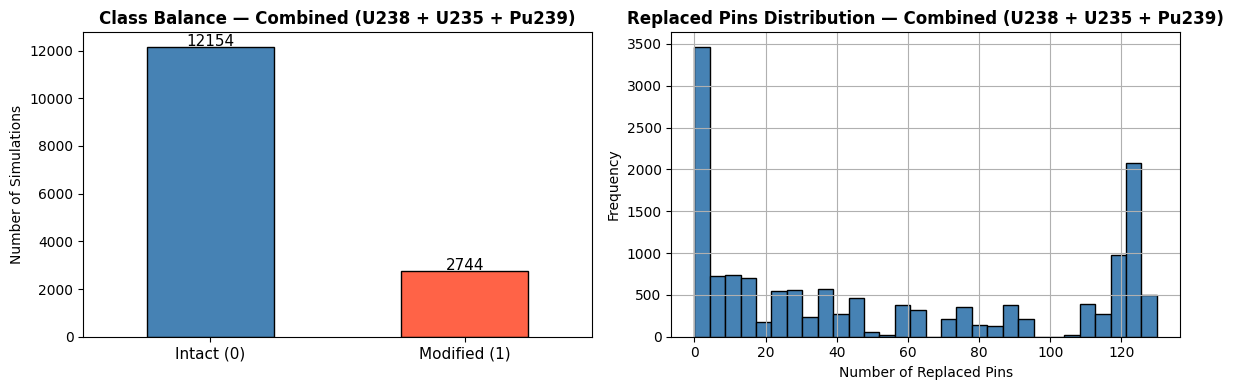

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clf['MODab_Flag'].value_counts().plot.bar(
    ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_xticklabels(['Intact (0)', 'Modified (1)'], rotation=0, fontsize=11)
axes[0].set_title('Class Balance — Combined (U238 + U235 + Pu239)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Simulations')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

df_reg['Total Replaced Pins'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Replaced Pins Distribution — Combined (U238 + U235 + Pu239)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Replaced Pins')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Combined_(U238_+_U235_+_Pu239)_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Helper Functions

In [4]:
def prepare_clf(df):
    cols_drop = ['MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['MODab_Flag']
    return X, y


def prepare_reg(df):
    cols_drop = ['Total Replaced Pins', 'MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['Total Replaced Pins']
    return X, y


def cv_classification(model, X, y, n=N_FOLDS):
    skf = StratifiedKFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=skf,
        scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted','roc_auc'])
    return pd.DataFrame({
        'Fold':      range(1, n+1),
        'Accuracy':  scores['test_accuracy'].round(4),
        'Precision': scores['test_precision_weighted'].round(4),
        'Recall':    scores['test_recall_weighted'].round(4),
        'F1':        scores['test_f1_weighted'].round(4),
        'AUC':       scores['test_roc_auc'].round(4),
    })


def cv_regression(model, X, y, n=N_FOLDS):
    kf = KFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=kf,
        scoring=['neg_mean_absolute_error','neg_root_mean_squared_error','r2'])
    return pd.DataFrame({
        'Fold': range(1, n+1),
        'MAE':  (-scores['test_neg_mean_absolute_error']).round(4),
        'RMSE': (-scores['test_neg_root_mean_squared_error']).round(4),
        'R2':   scores['test_r2'].round(4),
    })


def eval_classifier(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_te, y_proba)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1:        {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Intact','Modified'], yticklabels=['Intact','Modified'])
    axes[0].set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[1].plot([0,1],[0,1],'k--',lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {name}', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_clf.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC': round(auc,4)}


def eval_regressor(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(y_te, y_pred, alpha=0.3, s=8, color='steelblue')
    mn = min(y_te.min(), y_pred.min()); mx = max(y_te.max(), y_pred.max())
    axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect fit')
    axes[0].set_xlabel('Actual Replaced Pins'); axes[0].set_ylabel('Predicted Replaced Pins')
    axes[0].set_title(f'Prediction Error — {name}', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].text(0.05, 0.92, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}',
                 transform=axes[0].transAxes, fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    residuals = y_te - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='tomato')
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted Replaced Pins'); axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residuals Plot — {name}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_reg.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

print('Helper functions defined.')

Helper functions defined.


## 5. Define Models

In [5]:
classifiers = {
    'Extra Trees Classifier': ExtraTreesClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'KNN Classifier': KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Classifier': lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}

regressors = {
    'Extra Trees Regressor': ExtraTreesRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, random_state=RANDOM_STATE
    ),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, random_state=RANDOM_STATE
    ),
    'KNN Regressor': KNeighborsRegressor(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Regressor': lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        random_state=RANDOM_STATE, verbose=-1
    ),
}
print('Models defined.')

Models defined.


## 6. Prepare Train / Test Sets

In [6]:
# Classification
X_clf, y_clf = prepare_clf(df_clf)
scaler_clf   = StandardScaler()
X_clf_sc     = scaler_clf.fit_transform(X_clf)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf_sc, y_clf, test_size=TEST_SIZE, random_state=42, stratify=y_clf)

print(f'Classification — Train: {X_tr_c.shape}, Test: {X_te_c.shape}')
print(f'Features: {X_clf.shape[1]}')

# Regression
X_reg, y_reg = prepare_reg(df_reg)
scaler_reg   = StandardScaler()
X_reg_sc     = scaler_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_sc, y_reg, test_size=TEST_SIZE, random_state=42)

print(f'\nRegression — Train: {X_tr_r.shape}, Test: {X_te_r.shape}')

Classification — Train: (11918, 195), Test: (2980, 195)
Features: 195

Regression — Train: (11918, 195), Test: (2980, 195)


## 7. Classification — Combined (U238 + U235 + Pu239)
**Task:** Predict whether the fuel assembly has replaced pins (0=intact, 1=modified)

### 7.1 Extra Trees Classifier

In [7]:
# Cross-Validation
print('--- Extra Trees Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Extra Trees Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Extra Trees Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9953     0.9953  0.9953 0.9953 0.9999
    2    0.9953     0.9953  0.9953 0.9953 0.9998
    3    0.9966     0.9967  0.9966 0.9966 0.9995
    4    0.9950     0.9950  0.9950 0.9949 0.9999
    5    0.9936     0.9937  0.9936 0.9936 0.9984
Mean Accuracy: 0.9952 ± 0.0011
Mean AUC:      0.9995 ± 0.0006



  Extra Trees Classifier
  Accuracy:  0.9926
  Precision: 0.9926
  Recall:    0.9926
  F1:        0.9926
  AUC-ROC:   0.9991

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       549
           1       0.99      1.00      1.00      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.98      0.99      2980
weighted avg       0.99      0.99      0.99      2980



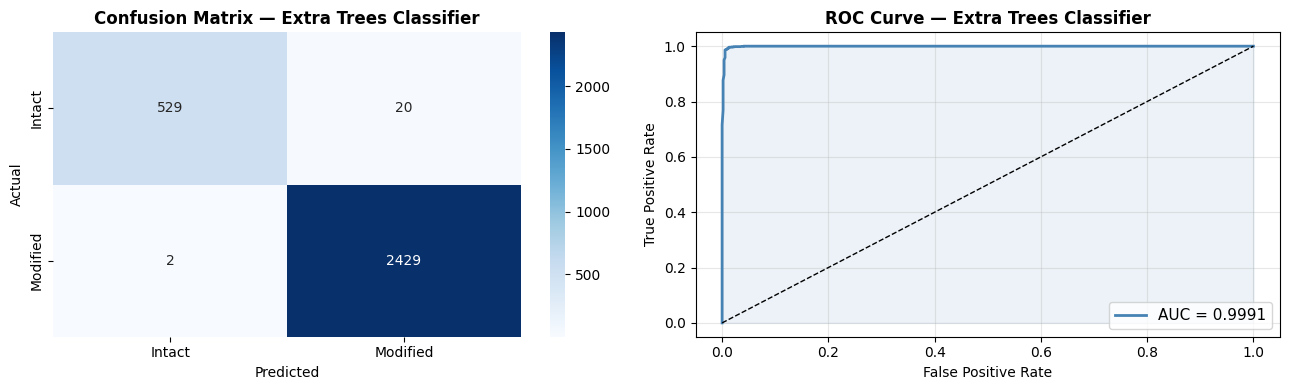

In [8]:
# Train & Evaluate
result_extra_trees_classifier = eval_classifier(
    copy.deepcopy(classifiers['Extra Trees Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Extra Trees Classifier'
)

### 7.2 Random Forest Classifier

In [9]:
# Cross-Validation
print('--- Random Forest Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Random Forest Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Random Forest Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9930     0.9930  0.9930 0.9929 0.9992
    2    0.9926     0.9926  0.9926 0.9926 0.9996
    3    0.9960     0.9960  0.9960 0.9960 0.9993
    4    0.9909     0.9910  0.9909 0.9909 0.9998
    5    0.9906     0.9907  0.9906 0.9905 0.9969
Mean Accuracy: 0.9926 ± 0.0022
Mean AUC:      0.9990 ± 0.0012



  Random Forest Classifier
  Accuracy:  0.9909
  Precision: 0.9909
  Recall:    0.9909
  F1:        0.9909
  AUC-ROC:   0.9987

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.98      0.98      2980
weighted avg       0.99      0.99      0.99      2980



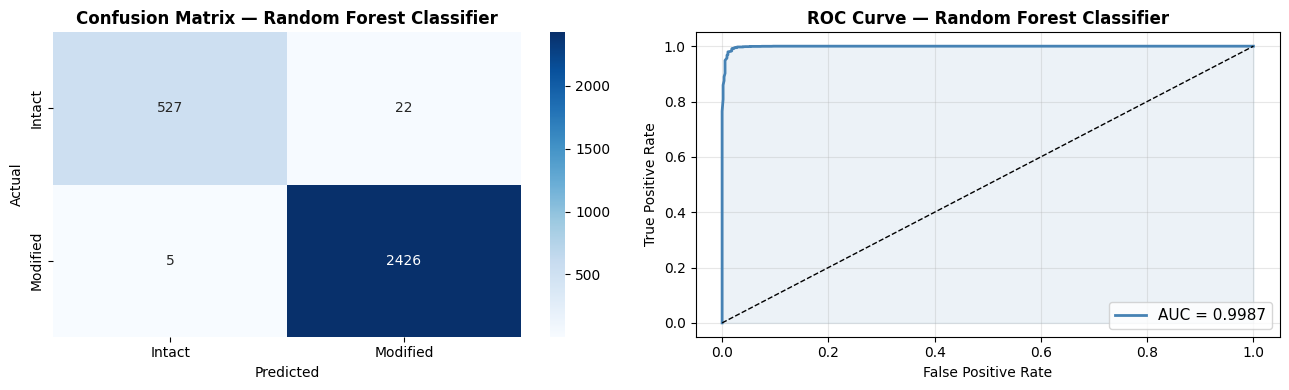

In [10]:
# Train & Evaluate
result_random_forest_classifier = eval_classifier(
    copy.deepcopy(classifiers['Random Forest Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Random Forest Classifier'
)

### 7.3 KNN Classifier

In [11]:
# Cross-Validation
print('--- KNN Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['KNN Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- KNN Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9644     0.9685  0.9644 0.9654 0.9918
    2    0.9721     0.9747  0.9721 0.9727 0.9951
    3    0.9691     0.9730  0.9691 0.9700 0.9964
    4    0.9634     0.9681  0.9634 0.9645 0.9953
    5    0.9550     0.9613  0.9550 0.9565 0.9896
Mean Accuracy: 0.9648 ± 0.0065
Mean AUC:      0.9936 ± 0.0028



  KNN Classifier
  Accuracy:  0.9688
  Precision: 0.9725
  Recall:    0.9688
  F1:        0.9696
  AUC-ROC:   0.9940

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       549
           1       1.00      0.96      0.98      2431

    accuracy                           0.97      2980
   macro avg       0.93      0.98      0.95      2980
weighted avg       0.97      0.97      0.97      2980



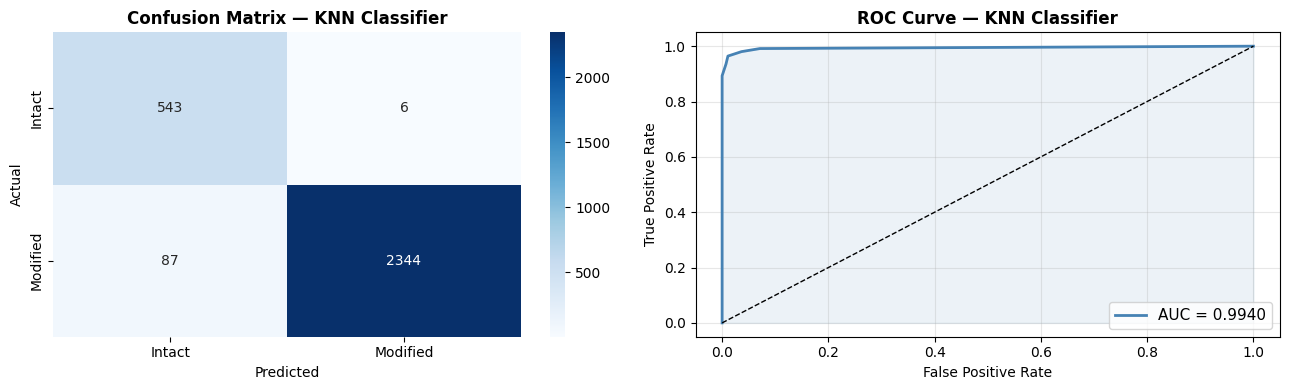

In [12]:
# Train & Evaluate
result_knn_classifier = eval_classifier(
    copy.deepcopy(classifiers['KNN Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'KNN Classifier'
)

### 7.4 LGBM Classifier

In [13]:
# Cross-Validation
print('--- LGBM Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['LGBM Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- LGBM Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9919     0.9920  0.9919 0.9920 0.9990
    2    0.9923     0.9923  0.9923 0.9923 0.9995
    3    0.9872     0.9876  0.9872 0.9873 0.9994
    4    0.9923     0.9924  0.9923 0.9923 0.9996
    5    0.9903     0.9903  0.9903 0.9903 0.9987
Mean Accuracy: 0.9908 ± 0.0022
Mean AUC:      0.9992 ± 0.0004



  LGBM Classifier
  Accuracy:  0.9889
  Precision: 0.9890
  Recall:    0.9889
  F1:        0.9890
  AUC-ROC:   0.9990

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       549
           1       1.00      0.99      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.98      0.98      0.98      2980
weighted avg       0.99      0.99      0.99      2980



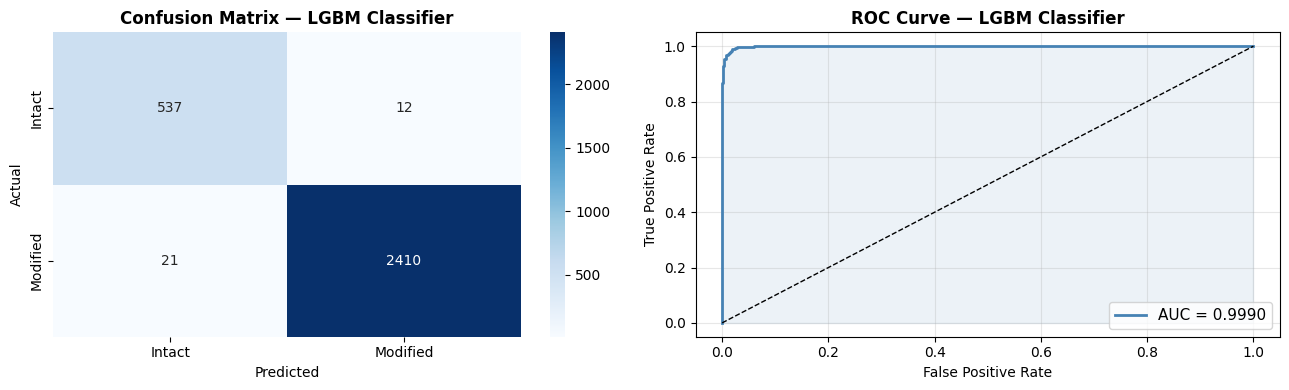

In [14]:
# Train & Evaluate
result_lgbm_classifier = eval_classifier(
    copy.deepcopy(classifiers['LGBM Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'LGBM Classifier'
)

### 7.5 Classification Summary

                   Model  Accuracy  Precision  Recall     F1    AUC
  Extra Trees Classifier    0.9926     0.9926  0.9926 0.9926 0.9991
Random Forest Classifier    0.9909     0.9909  0.9909 0.9909 0.9987
          KNN Classifier    0.9688     0.9725  0.9688 0.9696 0.9940
         LGBM Classifier    0.9889     0.9890  0.9889 0.9890 0.9990


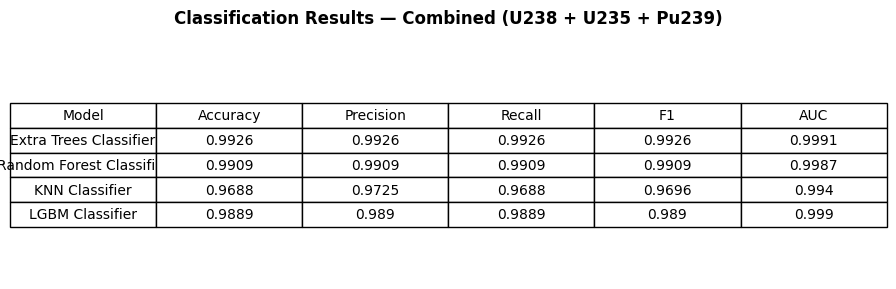

In [15]:
clf_summary = pd.DataFrame([
    result_extra_trees_classifier,
    result_random_forest_classifier,
    result_knn_classifier,
    result_lgbm_classifier,
])
print(clf_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
tbl = ax.table(cellText=clf_summary.values, colLabels=clf_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Classification Results — Combined (U238 + U235 + Pu239)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('classification_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Regression — Combined (U238 + U235 + Pu239)
**Task:** Predict the exact number of replaced pins (0–130)

### 8.1 Extra Trees Regressor

In [16]:
# Cross-Validation
print('--- Extra Trees Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Extra Trees Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Extra Trees Regressor | 5-Fold Cross-Validation ---
 Fold    MAE   RMSE     R2
    1 3.6619 7.1041 0.9788
    2 3.4932 6.7118 0.9811
    3 3.6121 7.2521 0.9784
    4 3.7637 7.0907 0.9792
    5 3.6323 6.9765 0.9792
Mean MAE:  3.6326 ± 0.0973
Mean RMSE: 7.0270 ± 0.2016
Mean R²:   0.9793 ± 0.0010



  Extra Trees Regressor
  MAE:  3.5922
  RMSE: 7.2929
  R²:   0.9782


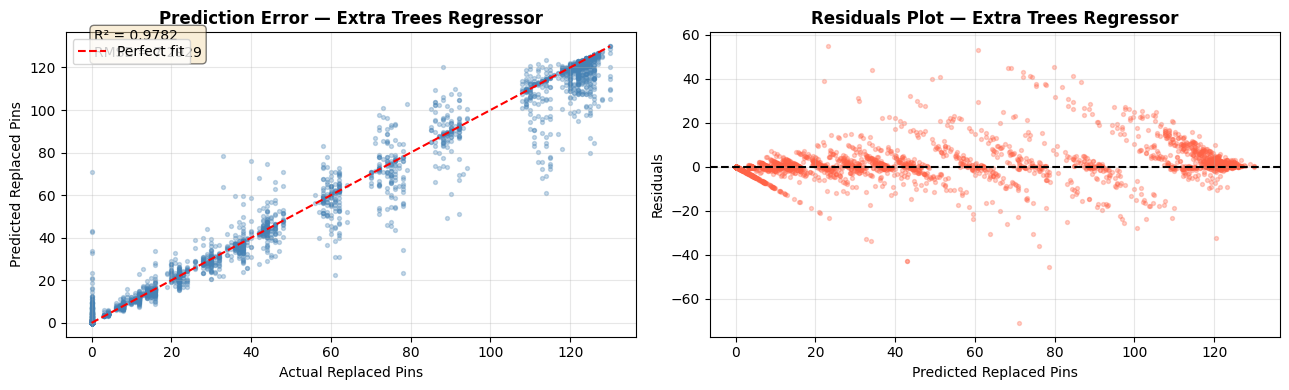

In [17]:
# Train & Evaluate
result_extra_trees_regressor = eval_regressor(
    copy.deepcopy(regressors['Extra Trees Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Extra Trees Regressor'
)

### 8.2 Random Forest Regressor

In [18]:
# Cross-Validation
print('--- Random Forest Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Random Forest Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Random Forest Regressor | 5-Fold Cross-Validation ---
 Fold    MAE   RMSE     R2
    1 4.1800 7.7220 0.9749
    2 3.9078 7.0174 0.9793
    3 4.1127 7.7543 0.9754
    4 4.2701 7.9115 0.9741
    5 4.0709 7.5169 0.9758
Mean MAE:  4.1083 ± 0.1350
Mean RMSE: 7.5844 ± 0.3467
Mean R²:   0.9759 ± 0.0020



  Random Forest Regressor
  MAE:  4.0691
  RMSE: 7.7422
  R²:   0.9754


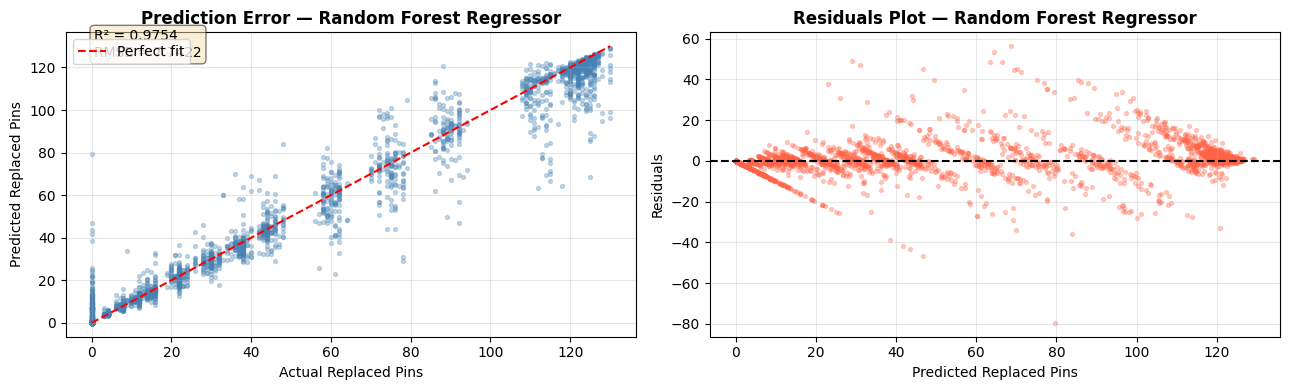

In [19]:
# Train & Evaluate
result_random_forest_regressor = eval_regressor(
    copy.deepcopy(regressors['Random Forest Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Random Forest Regressor'
)

### 8.3 KNN Regressor

In [20]:
# Cross-Validation
print('--- KNN Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['KNN Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- KNN Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 5.4487 13.5327 0.9230
    2 5.3634 13.2565 0.9261
    3 5.1297 12.5186 0.9358
    4 5.4598 13.2945 0.9268
    5 5.1133 12.5189 0.9330
Mean MAE:  5.3030 ± 0.1699
Mean RMSE: 13.0242 ± 0.4734
Mean R²:   0.9289 ± 0.0053



  KNN Regressor
  MAE:  5.2468
  RMSE: 12.9385
  R²:   0.9313


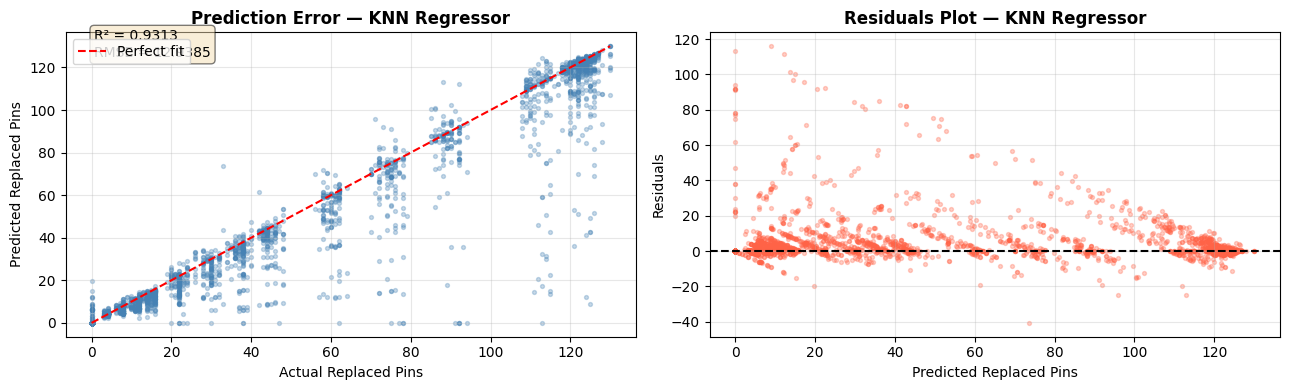

In [21]:
# Train & Evaluate
result_knn_regressor = eval_regressor(
    copy.deepcopy(regressors['KNN Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'KNN Regressor'
)

### 8.4 LGBM Regressor

In [22]:
# Cross-Validation
print('--- LGBM Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['LGBM Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- LGBM Regressor | 5-Fold Cross-Validation ---
 Fold    MAE   RMSE     R2
    1 4.7138 7.5869 0.9758
    2 4.5050 7.6316 0.9755
    3 4.5583 7.6237 0.9762
    4 4.7280 7.7833 0.9749
    5 4.5450 7.3885 0.9767
Mean MAE:  4.6100 ± 0.1032
Mean RMSE: 7.6028 ± 0.1414
Mean R²:   0.9758 ± 0.0007



  LGBM Regressor
  MAE:  4.4256
  RMSE: 7.2355
  R²:   0.9785


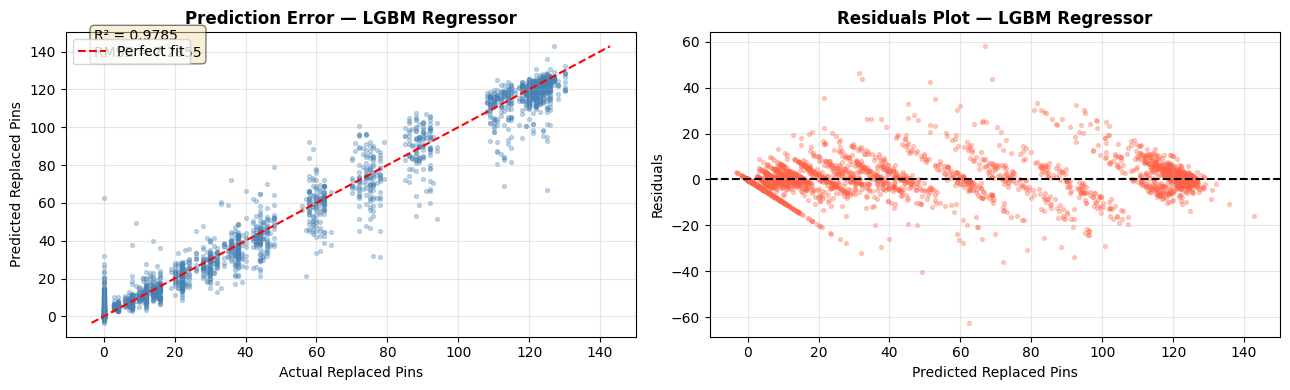

In [23]:
# Train & Evaluate
result_lgbm_regressor = eval_regressor(
    copy.deepcopy(regressors['LGBM Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'LGBM Regressor'
)

### 8.5 Regression Summary

                  Model    MAE    RMSE     R2
  Extra Trees Regressor 3.5922  7.2929 0.9782
Random Forest Regressor 4.0691  7.7422 0.9754
          KNN Regressor 5.2468 12.9385 0.9313
         LGBM Regressor 4.4256  7.2355 0.9785


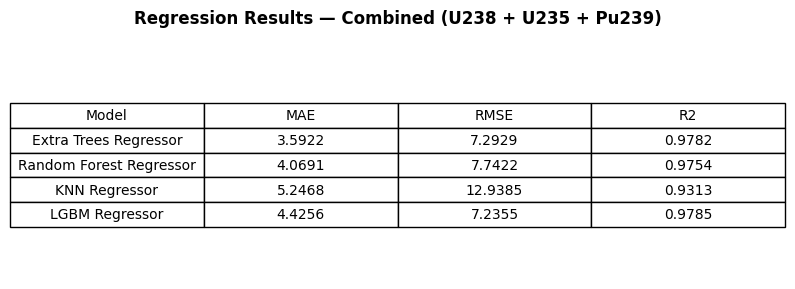

In [24]:
reg_summary = pd.DataFrame([
    result_extra_trees_regressor,
    result_random_forest_regressor,
    result_knn_regressor,
    result_lgbm_regressor,
])
print(reg_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = ax.table(cellText=reg_summary.values, colLabels=reg_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Regression Results — Combined (U238 + U235 + Pu239)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('regression_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results

In [25]:
with pd.ExcelWriter('Combined_(U238_+_U235_+_Pu239)_results.xlsx') as writer:
    clf_summary.to_excel(writer, sheet_name='Classification', index=False)
    reg_summary.to_excel(writer, sheet_name='Regression', index=False)

print('Results saved to Combined_(U238_+_U235_+_Pu239)_results.xlsx')

Results saved to Combined_(U238_+_U235_+_Pu239)_results.xlsx
